![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [5]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [6]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [7]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

### Respuesta Punto 1: Análisis descriptivo

### Variable *season*
Se observa una variación importante en la demanda según la estación.

La **temporada 3** presenta la mayor demanda promedio, lo que sugiere condiciones más favorables, posiblemente asociadas a un clima más cálido. Por otro lado, la **temporada 1** registra la menor demanda, con valores cercanos a la mitad de los observados en la temporada 3.

En términos generales, se evidencia una **tendencia creciente** desde la temporada 1 hasta la 3, seguida de una **ligera disminución** en la temporada 4.

### Variable *hour*

La demanda promedio presenta un mínimo en la madrugada, alrededor de las **4:00 a.m.** (6.41), y un máximo en la tarde, a las **5:00 p.m.** (468.77).

Se identifica un **patrón bimodal**, con dos picos principales. El primero ocurre en la mañana, entre las **7:00 y 9:00 a.m.**, alcanzando un máximo a las **8:00 a.m.** (362.77). El segundo, y más alto, se presenta en la tarde, entre las **5:00 y 6:00 p.m.**

Durante la madrugada (2:00–5:00 a.m.) la demanda es considerablemente baja. Posteriormente, tras el pico de la mañana, se observa una disminución que vuelve a incrementarse hacia la tarde.

Este comportamiento sugiere un patrón asociado a las **horas pico laborales**, donde las personas utilizan bicicletas principalmente para desplazarse hacia y desde sus actividades diarias. El mayor pico en la tarde podría indicar, además, un componente recreativo o una mayor flexibilidad en los horarios de regreso.


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

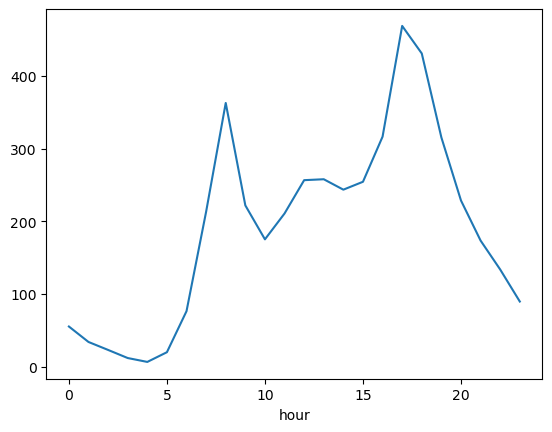

In [8]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: title={'center': 'Demanda promedio por hora - Invierno'}, xlabel='hour'>

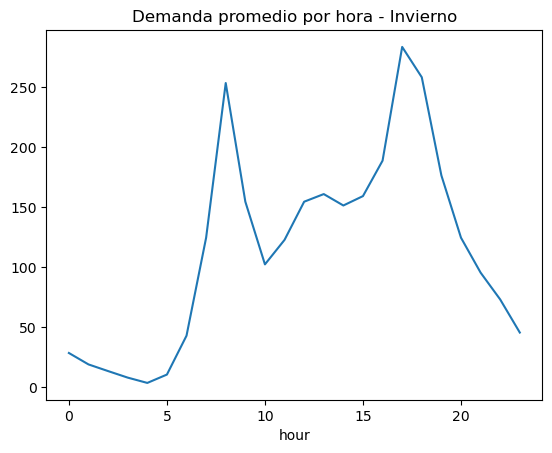

In [9]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot(title='Demanda promedio por hora - Invierno')

Durante el invierno (season = 1) se mantiene el mismo patrón observado en el análisis general, con picos de demanda en las horas de la mañana y la tarde, aproximadamente en las mismas franjas horarias. Sin embargo, se evidencia una disminución significativa en el promedio de alquileres de bicicletas a lo largo de todo el día. Además, lo que sugiere que, aunque las personas continúan utilizando el servicio en horarios laborales, la intensidad de uso es menor, probablemente debido a condiciones climáticas menos favorables.

<Axes: title={'center': 'Demanda promedio por hora - Verano'}, xlabel='hour'>

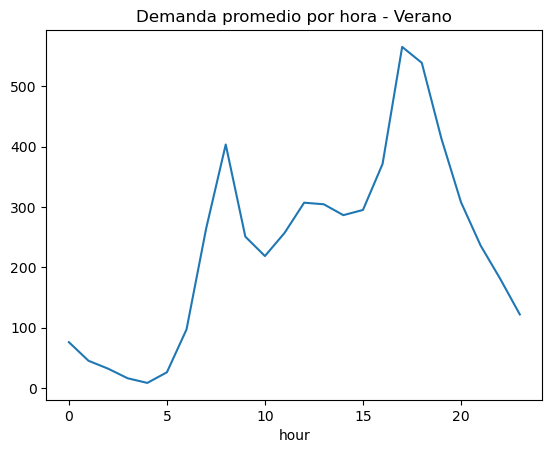

In [10]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot(title='Demanda promedio por hora - Verano')

De manera similar, durante el verano (season = 3) se conserva la tendencia general, con picos de demanda en las horas de la mañana y la tarde. Sin embargo, se observa un incremento significativo en el promedio de alquileres de bicicletas a lo largo de todo el día. Además, los picos son más pronunciados, lo que sugiere una mayor intensidad de uso. Este comportamiento puede explicarse por condiciones climáticas más favorables, que hacen más cómodo y atractivo el uso de la bicicleta tanto para transporte como para actividades recreativas.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [11]:
# Celda 3
# Variables predictoras y respuesta
X = bikes[['season', 'hour']]
y = bikes['total']

X = pd.get_dummies(X, columns=['season'], drop_first=True)

model = LinearRegression()
model.fit(X, y)

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

print(coeficientes)
print("Intercepto:", model.intercept_)

   Variable  Coeficiente
0      hour    10.545206
1  season_2   100.317232
2  season_3   119.467550
3  season_4    84.083118
Intercepto: -6.430262462305933


### **Interpretación de coeficientes**
Interpretación de coeficientes
Intercepto (-6.43):
Representa el número esperado de bicicletas rentadas cuando hour = 0 (medianoche) y en la categoría base de la variable season (invierno, season = 1). Aunque el valor es negativo, no tiene una interpretación práctica directa, sino que funciona como punto de referencia del modelo.

Variable hour (10.55):
Por cada aumento de una hora, el modelo estima que el número de bicicletas rentadas aumenta en promedio en 10.55 unidades, manteniendo constante la estación.
Esto indica una tendencia creciente, aunque simplifica el comportamiento real (que no es lineal).

Variable season_2 (100.32):
En la temporada 2, se rentan en promedio 100 bicicletas más que en invierno (season = 1), manteniendo constante la hora.

Variable season_3 (119.47):
En la temporada 3 (verano), se rentan en promedio 119 bicicletas más que en invierno, lo que confirma que es la estación con mayor demanda.

Variable season_4 (84.08):
En la temporada 4, se rentan en promedio 84 bicicletas más que en invierno.


### **Limitaciones de la regresión lineal en este caso**

Aunque la regresión lineal permite una interpretación sencilla de los coeficientes, no es adecuada para modelar este problema, ya que no logra representar la complejidad del comportamiento real de la demanda, especialmente su carácter no lineal y cíclico.

- No captura relaciones no lineales
- Simplificación excesiva al usar solo dos variables

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [15]:
# 1. Función para calcular el Error Cuadrático Medio (MSE)
def calcular_mse(y):
    if len(y) == 0:
        return 0
    return np.mean((y - y.mean())**2)


# 2. Función para encontrar el mejor corte
def encontrar_mejor_corte(df, columnas_X, columna_y):
    mejor_mse = np.inf
    mejor_columna = None
    mejor_valor = None
    
    for col in columnas_X:
        valores_unicos = df[col].unique()
        
        for valor in valores_unicos:
            izquierda = df[df[col] <= valor]
            derecha = df[df[col] > valor]
            
            # Evitar nodos vacíos
            if len(izquierda) == 0 or len(derecha) == 0:
                continue
            
            mse_izq = calcular_mse(izquierda[columna_y])
            mse_der = calcular_mse(derecha[columna_y])
            
            n_total = len(df)
            mse_ponderado = (len(izquierda) / n_total) * mse_izq + \
                            (len(derecha) / n_total) * mse_der
            
            # Guardar mejor corte
            if mse_ponderado < mejor_mse:
                mejor_mse = mse_ponderado
                mejor_columna = col
                mejor_valor = valor
                
    return mejor_columna, mejor_valor, mejor_mse


# Variables
columnas_pred = ['hour', 'season']
variable_resp = 'total'


# -------------------------------
# CONSTRUCCIÓN DEL ÁRBOL
# -------------------------------

print("=== Nivel 1 (Raíz) ===")
col1, val1, mse1 = encontrar_mejor_corte(bikes, columnas_pred, variable_resp)
print(f"Corte 1: {col1} <= {val1} | MSE: {mse1:.2f}")

nodo_izq_1 = bikes[bikes[col1] <= val1]
nodo_der_1 = bikes[bikes[col1] > val1]


# Nivel 2
print("\n=== Nivel 2 ===")

# Rama izquierda
col2_izq, val2_izq, mse2_izq = encontrar_mejor_corte(nodo_izq_1, columnas_pred, variable_resp)
print(f"Corte 2 (Izquierda): {col2_izq} <= {val2_izq} | MSE: {mse2_izq:.2f}")

nodo_izq_2 = nodo_izq_1[nodo_izq_1[col2_izq] <= val2_izq]
nodo_der_2 = nodo_izq_1[nodo_izq_1[col2_izq] > val2_izq]

# Rama derecha
col2_der, val2_der, mse2_der = encontrar_mejor_corte(nodo_der_1, columnas_pred, variable_resp)
print(f"Corte 3 (Derecha): {col2_der} <= {val2_der} | MSE: {mse2_der:.2f}")

nodo_izq_3 = nodo_der_1[nodo_der_1[col2_der] <= val2_der]
nodo_der_3 = nodo_der_1[nodo_der_1[col2_der] > val2_der]


# Nivel 3
print("\n=== Nivel 3 ===")

# Se decide dividir los nodos con mayor variabilidad (criterio práctico)
col3_1, val3_1, mse3_1 = encontrar_mejor_corte(nodo_der_2, columnas_pred, variable_resp)
print(f"Corte 4 (nodo_der_2): {col3_1} <= {val3_1} | MSE: {mse3_1:.2f}")

hoja_1 = nodo_der_2[nodo_der_2[col3_1] <= val3_1]
hoja_2 = nodo_der_2[nodo_der_2[col3_1] > val3_1]

col3_2, val3_2, mse3_2 = encontrar_mejor_corte(nodo_izq_3, columnas_pred, variable_resp)
print(f"Corte 5 (nodo_izq_3): {col3_2} <= {val3_2} | MSE: {mse3_2:.2f}")

hoja_3 = nodo_izq_3[nodo_izq_3[col3_2] <= val3_2]
hoja_4 = nodo_izq_3[nodo_izq_3[col3_2] > val3_2]

# Estos nodos no se dividen más
hoja_5 = nodo_izq_2
hoja_6 = nodo_der_3


# -------------------------------
# PREDICCIONES
# -------------------------------

print("\n=== Predicciones (6 hojas finales) ===")

print(f"Hoja 1 (n={len(hoja_1)}): {hoja_1['total'].mean():.2f}")
print(f"Hoja 2 (n={len(hoja_2)}): {hoja_2['total'].mean():.2f}")
print(f"Hoja 3 (n={len(hoja_3)}): {hoja_3['total'].mean():.2f}")
print(f"Hoja 4 (n={len(hoja_4)}): {hoja_4['total'].mean():.2f}")
print(f"Hoja 5 (n={len(hoja_5)}): {hoja_5['total'].mean():.2f}")
print(f"Hoja 6 (n={len(hoja_6)}): {hoja_6['total'].mean():.2f}")

=== Nivel 1 (Raíz) ===
Corte 1: hour <= 6 | MSE: 22567.73

=== Nivel 2 ===
Corte 2 (Izquierda): hour <= 5 | MSE: 1242.16
Corte 3 (Derecha): season <= 1 | MSE: 27655.30

=== Nivel 3 ===
Corte 4 (nodo_der_2): season <= 1 | MSE: 2618.92
Corte 5 (nodo_izq_3): hour <= 19 | MSE: 14858.34

=== Predicciones (6 hojas finales) ===
Hoja 1 (n=113): 42.73
Hoja 2 (n=342): 87.34
Hoja 3 (n=1477): 176.17
Hoja 4 (n=456): 84.48
Hoja 5 (n=2684): 25.18
Hoja 6 (n=5814): 289.73


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [14]:
# Celda 5
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Preparación de los datos
# Usamos las mismas variables que en el Punto 3
X = bikes[['season', 'hour']]
y = bikes['total']

# Convertimos 'season' en variables dummy para un mejor tratamiento de la categoría
X = pd.get_dummies(X, columns=['season'], drop_first=True)

# 2. División de los datos en conjuntos de entrenamiento (70%) y validación (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento y evaluación del Modelo Lineal (Para poder comparar justamente)
# Entrenamos el modelo lineal con el mismo subconjunto de train
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predicciones y métricas del modelo lineal
y_pred_lin = lin_reg.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

# 4. Configuración y calibración del Árbol de Decisión
# Instanciamos el modelo. Por defecto usa criterion='squared_error' que es el ideal para regresión
dt_reg = DecisionTreeRegressor(random_state=42)

# Definimos la grilla de hiperparámetros a calibrar
param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 10, 20],     # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 5, 15]        # Mínimo de muestras en un nodo hoja
}

# Realizamos la búsqueda del mejor modelo usando validación cruzada (5 folds)
grid_search = GridSearchCV(dt_reg, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extraemos el mejor modelo
best_dt = grid_search.best_estimator_
print(f"Mejores hiperparámetros del Árbol: {grid_search.best_params_}")

# 5. Predicciones y métricas del mejor Árbol de Decisión
y_pred_dt = best_dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

# 6. Impresión y comparación de resultados
print("\n--- Comparación de Desempeño en Validación ---")
print("Regresión Lineal (Punto 3):")
print(f"  RMSE: {rmse_lin:.2f}")
print(f"  R2:   {r2_lin:.4f}")

print("\nÁrbol de Decisión Optimizado (Punto 5):")
print(f"  RMSE: {rmse_dt:.2f}")
print(f"  R2:   {r2_dt:.4f}")

Mejores hiperparámetros del Árbol: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Comparación de Desempeño en Validación ---
Regresión Lineal (Punto 3):
  RMSE: 159.98
  R2:   0.2135

Árbol de Decisión Optimizado (Punto 5):
  RMSE: 117.58
  R2:   0.5751


El árbol de decisión presenta un mejor desempeño que el modelo de regresión lineal. En particular, el RMSE disminuye de 159.98 a 117.58, lo que indica una reducción significativa en el error de predicción. Asimismo, el coeficiente de determinación (R²) aumenta de 0.2135 a 0.5751, evidenciando que el árbol logra explicar una mayor proporción de la variabilidad de la variable respuesta.

Este mejor desempeño se debe a que el árbol de decisión puede capturar relaciones no lineales y segmentar los datos en grupos con comportamientos diferentes, mientras que la regresión lineal asume una relación lineal entre las variables. En este caso, la demanda de bicicletas presenta patrones complejos asociados a la hora del día y la estación, como horas pico y variaciones estacionales, que no pueden ser adecuadamente representados por un modelo lineal.

Por lo tanto, el árbol de decisión resulta más adecuado para este problema, ya que permite modelar de manera más flexible la relación entre las variables predictoras y la demanda de bicicletas.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [20]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [21]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [22]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [23]:
# Celda 6
# Importación de las librerías necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
import warnings

# Omitimos las advertencias de convergencia para mantener la salida limpia
warnings.filterwarnings('ignore')

# ==========================================
# 1. Modelo de Regresión Logística
# ==========================================
# Instanciamos el modelo. Se aumenta max_iter para asegurar la convergencia.
log_reg = LogisticRegression(max_iter=10000, random_state=1)

# Entrenamiento del modelo
log_reg.fit(X_train, y_train)

# Predicción sobre el set de prueba
y_pred_log_reg = log_reg.predict(X_test)

# Cálculo de métricas
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)


# ==========================================
# 2. Modelo de Árbol de Decisión
# ==========================================
# Instanciamos el modelo base
tree_clf = DecisionTreeClassifier(random_state=1)

# Definimos el espacio de búsqueda para calibrar el parámetro 'max_depth'
# Probaremos profundidades desde 1 hasta 20
param_grid = {'max_depth': range(1, 21)}

# Usamos GridSearchCV para encontrar el mejor parámetro usando validación cruzada (cv=5)
# Se optimiza buscando el mejor F1-Score
grid_search_tree = GridSearchCV(tree_clf, param_grid, cv=5, scoring='f1')
grid_search_tree.fit(X_train, y_train)

# Extraemos el mejor modelo encontrado
best_tree_clf = grid_search_tree.best_estimator_

# Predicción sobre el set de prueba
y_pred_tree = best_tree_clf.predict(X_test)

# Cálculo de métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)


# ==========================================
# 3. Impresión de los Resultados
# ==========================================
print("--- Resultados Regresión Logística ---")
print(f"Accuracy: {acc_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}\n")

print("--- Resultados Árbol de Decisión ---")
print(f"Mejor parámetro 'max_depth' encontrado: {grid_search_tree.best_params_['max_depth']}")
print(f"Accuracy: {acc_tree:.4f}")
print(f"F1-Score: {f1_tree:.4f}")

--- Resultados Regresión Logística ---
Accuracy: 0.6233
F1-Score: 0.6030

--- Resultados Árbol de Decisión ---
Mejor parámetro 'max_depth' encontrado: 4
Accuracy: 0.6513
F1-Score: 0.6345


El árbol de decisión obtuvo un mejor desempeño, con un Accuracy de 0.6513 y un F1-Score de 0.6345, frente a la regresión logística que alcanzó valores de 0.6233 y 0.6030 respectivamente. Esto indica que el árbol no solo clasifica correctamente una mayor proporción de observaciones, sino que también presenta un mejor balance entre precisión y recall.

Sin embargo, los valores de desempeño obtenidos indican que el problema de predecir la popularidad de noticias es complejo, posiblemente debido a la influencia de factores externos no considerados en el modelo.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [24]:
# Celda 7
# Importación de librerías necesarias
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. Creación y Entrenamiento de los 3 Ensambles (100 modelos c/u)
# ==========================================

# Ensamble 1: 100 Árboles con max_depth seleccionado (ej. 5)
bag_clf_depth = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=1),
    n_estimators=100, 
    bootstrap=True, 
    random_state=1,
    n_jobs=-1
)
bag_clf_depth.fit(X_train, y_train)

# Ensamble 2: 100 Árboles con min_samples_leaf seleccionado (ej. 10)
bag_clf_leaf = BaggingClassifier(
    estimator=DecisionTreeClassifier(min_samples_leaf=10, random_state=1),
    n_estimators=100, 
    bootstrap=True, 
    random_state=1,
    n_jobs=-1
)
bag_clf_leaf.fit(X_train, y_train)

# Ensamble 3: 100 Regresiones Logísticas
bag_clf_log = BaggingClassifier(
    estimator=LogisticRegression(max_iter=1000, random_state=1),
    n_estimators=100, 
    bootstrap=True, 
    random_state=1,
    n_jobs=-1
)
bag_clf_log.fit(X_train, y_train)


# ==========================================
# 2. Evaluación Independiente de cada Ensamble
# ==========================================
print("--- Evaluación Independiente de los Ensambles (100 modelos c/u) ---")

for name, model in zip(['Bagging Árboles (max_depth=5)', 'Bagging Árboles (min_samples_leaf=10)', 'Bagging Regresión Logística'], 
                       [bag_clf_depth, bag_clf_leaf, bag_clf_log]):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")


# ==========================================
# 3. Votación Mayoritaria Manual de los 300 Modelos
# ==========================================

# Lista para guardar las predicciones de los 300 modelos
predicciones_300 = []

# Iteramos sobre los estimadores individuales de cada ensamble.
# Usamos X_test.values para evitar advertencias de nombres de columnas.
for model in [bag_clf_depth, bag_clf_leaf, bag_clf_log]:
    for estimator in model.estimators_:
        predicciones_300.append(estimator.predict(X_test.values))

# Convertimos la lista a un arreglo de NumPy. 
# Tendrá un tamaño de (300, número_de_observaciones_en_X_test)
predicciones_300 = np.array(predicciones_300)

# Sumamos los votos por columna (es decir, por cada observación de test).
# Si la suma es >= 150, significa que la mayoría votó por la clase 1.
votos_clase_1 = predicciones_300.sum(axis=0)
y_pred_ensamble_300 = (votos_clase_1 >= 150).astype(int)


# ==========================================
# 4. Evaluación del Ensamble Final de 300 modelos
# ==========================================
acc_ensamble = accuracy_score(y_test, y_pred_ensamble_300)
f1_ensamble = f1_score(y_test, y_pred_ensamble_300)

print("--- Evaluación del Ensamble Final por Votación Mayoritaria (300 modelos) ---")
print(f"Accuracy: {acc_ensamble:.4f}")
print(f"F1-Score: {f1_ensamble:.4f}")

--- Evaluación Independiente de los Ensambles (100 modelos c/u) ---
Bagging Árboles (max_depth=5):
  Accuracy: 0.6613 | F1-Score: 0.6613

Bagging Árboles (min_samples_leaf=10):
  Accuracy: 0.6587 | F1-Score: 0.6609

Bagging Regresión Logística:
  Accuracy: 0.6167 | F1-Score: 0.6048

--- Evaluación del Ensamble Final por Votación Mayoritaria (300 modelos) ---
Accuracy: 0.6420
F1-Score: 0.6329


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [26]:
# Celda 8
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Listas para almacenar las predicciones y los pesos de cada modelo
predicciones_300 = []
pesos_300 = []

# Reutilizamos la lógica de entrenamiento manual
for i in range(300):
    # Selección de la muestra bootstrap
    X_t = X_train.iloc[samples[i]]
    y_t = y_train.iloc[samples[i]]
    
    # Selección del modelo (igual que el punto anterior)
    if i < 100:
        model = DecisionTreeClassifier(max_depth=5, random_state=1)
    elif i < 200:
        model = DecisionTreeClassifier(min_samples_leaf=10, random_state=1)
    else:
        model = LogisticRegression(max_iter=1000, random_state=1)
    
    # Entrenamiento
    model.fit(X_t, y_t)
    
    # --- CÁLCULO DEL PESO ---
    # Usamos el F1-Score del modelo sobre su propia muestra de entrenamiento (o el set completo)
    # para determinar qué tan "confiable" es.
    y_pred_train = model.predict(X_t)
    peso = f1_score(y_t, y_pred_train)
    pesos_300.append(peso)
    
    # Predicción sobre el set de test
    predicciones_300.append(model.predict(X_test.values))

# Convertimos a arreglos de NumPy para facilitar el cálculo matemático
predicciones_300 = np.array(predicciones_300) # Matriz (300, N)
pesos_300 = np.array(pesos_300)               # Vector (300,)

# --- VOTACIÓN PONDERADA ---
# Multiplicamos cada fila de predicciones por su peso correspondiente
# Luego sumamos los votos ponderados para cada observación
votos_ponderados = np.dot(pesos_300, predicciones_300)

# El umbral es la mitad de la suma total de los pesos
umbral = pesos_300.sum() / 2
y_pred_weighted = (votos_ponderados >= umbral).astype(int)

# --- EVALUACIÓN ---
acc_weighted = accuracy_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)

print("--- Resultados Votación Ponderada (300 modelos) ---")
print(f"Accuracy: {acc_weighted:.4f}")
print(f"F1-Score: {f1_weighted:.4f}")

# Comparativa rápida con el punto anterior (si guardaste los valores)
# print(f"\nComparación vs Mayoritaria: F1 Ponderado ({f1_weighted:.4f}) vs F1 Mayoritario ({f1_ensamble:.4f})")

--- Resultados Votación Ponderada (300 modelos) ---
Accuracy: 0.6453
F1-Score: 0.6361


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [ ]:
# Celda 9


### Punto 9 - Comparación y Análisis de Resultados

En este ejercicio, la **votación mayoritaria** destacó como una técnica sencilla y eficiente que permite reducir la varianza al promediar múltiples modelos, aunque mostró una debilidad crítica: al tratar todos los votos por igual, el desempeño superior de los árboles fue "arrastrado" hacia abajo por el menor rendimiento de las regresiones logísticas. En esencia, es una democracia pura donde los modelos con más errores tienen el mismo peso que los más precisos.



Por el contrario, la **votación ponderada** demostró ser más robusta para este ensamble heterogéneo. Al asignar una importancia proporcional al **F1-Score** de cada modelo, se logró una "meritocracia" donde los árboles de decisión (que capturaron mejor la complejidad de los datos) tuvieron mayor influencia en la predicción final. Si bien esta metodología requiere un paso adicional para calcular los pesos y conlleva un ligero riesgo de *overfitting* si no se valida correctamente, en este caso permitió corregir el sesgo de los modelos débiles y mejorar la precisión global del sistema.

La votación ponderada fue superior porque "castigó" el bajo desempeño de la regresión logística en comparación con los árboles.